# YOLOv8 Training for DepthAI

Simple training notebook for YOLOv8n model that can be deployed on OAK-D cameras.


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="Y0G66vmOV2YEL42JtXAX")
project = rf.workspace("coin-counter-sskgh").project("chess-bjirs")
version = project.version(8)
dataset = version.download("yolov11")


  Using cached roboflow-1.2.11-py3-none-any.whl.metadata (9.7 kB)
  Using cached idna-3.7-py3-none-any.whl.metadata (9.9 kB)
Using cached roboflow-1.2.11-py3-none-any.whl (89 kB)
Using cached idna-3.7-py3-none-any.whl (66 kB)
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Chess-8 in yolov11:: 100%|██████████| 204/204 [00:00<00:00, 3198.58it/s]


In [ ]:
# Install dependencies (run once)
!pip install ultralytics depthai


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 MB 10.9 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
from pathlib import Path

# =================== CONFIGURATION ===================
# Change these to match your dataset
DATA_PATH = "/content/Chess-8/data.yaml"
MODEL_SIZE = "n"  # Options: 'n' (nano), 's', 'm', 'l', 'x'
EPOCHS = 300
IMG_SIZE = 640
BATCH = 16
# ======================================================

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# Initialize model
print(f"Loading YOLOv11{MODEL_SIZE} model...")
model = YOLO(f'yolov11{MODEL_SIZE}.pt')

print(f"\n{'='*50}")
print(f"Training Configuration:")
print(f"  Model: YOLOv11{MODEL_SIZE}")
print(f"  Dataset: {DATA_PATH}")
print(f"  Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch size: {BATCH}")
print(f"  Epochs: {EPOCHS}")
print(f"{'='*50}\n")


Loading YOLOv11n model...


FileNotFoundError: [Errno 2] No such file or directory: 'yolov11n.pt'

In [ ]:
# Train the model
print("Starting training...\n")
results = model.train(
    data=DATA_PATH,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    save=True,
    val=True,
)


Starting training...

Ultralytics 8.3.226 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Chess-8/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.

In [ ]:
# Display results
print(f"\n{'='*50}")
print(f"Training completed!")
print(f"  Precision: {results.results_dict.get('metrics/precision(B)', 'N/A')}")
print(f"  Recall: {results.results_dict.get('metrics/recall(B)', 'N/A')}")
print(f"  mAP50: {results.results_dict.get('metrics/mAP50(B)', 'N/A')}")
print(f"  mAP50-95: {results.results_dict.get('metrics/mAP50-95(B)', 'N/A')}")
print(f"{'='*50}\n")



Training completed!
  Precision: 0.994210971279246
  Recall: 1.0
  mAP50: 0.995
  mAP50-95: 0.9453601190476192



In [ ]:
# Load the best model
best_model = YOLO('runs/detect/train/weights/best.pt')

# Get validation metrics
metrics = best_model.val()
print("\nValidation Metrics:")
print(f"  Precision: {metrics.results_dict.get('metrics/precision(B)', 'N/A')}")
print(f"  Recall: {metrics.results_dict.get('metrics/recall(B)', 'N/A')}")
print(f"  mAP50: {metrics.results_dict.get('metrics/mAP50(B)', 'N/A')}")
print(f"  mAP50-95: {metrics.results_dict.get('metrics/mAP50-95(B)', 'N/A')}")


Ultralytics 8.3.226 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1775.1±783.9 MB/s, size: 202.3 KB)
val: Scanning /content/Chess-8/valid/labels.cache... 19 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 19/19 41.1Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.1it/s 1.0s
                   all         19         19      0.994          1      0.995      0.941
            black-rook          7          7      0.992          1      0.995      0.957
          white-bishop         12         12      0.996          1      0.995      0.926
Speed: 10.8ms preprocess, 19.9ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/runs/detect/val

Validation Metrics:
  Precision: 0.9942048406016446
  Recall: 1.0
  mAP50: 0.995
  mAP50-95: 0.941360208

Inference


image 1/1 /content/Chess-8/train/images/image_20251107_161752_300_jpg.rf.ae03ce4b628a2eb63f35792f4cac5d84.jpg: 480x640 1 white-bishop, 45.2ms
Speed: 3.4ms preprocess, 45.2ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict


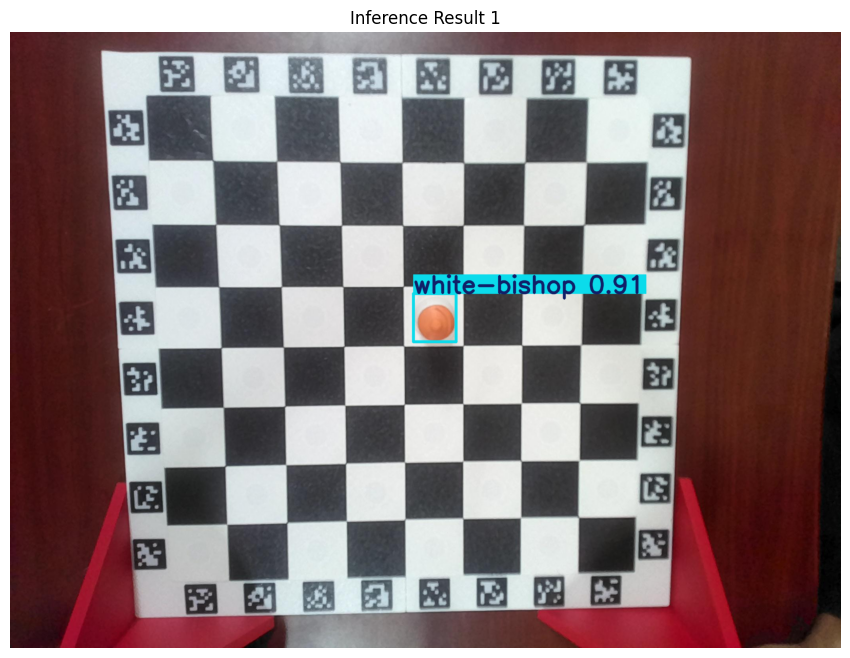


Image 1 - Detections found: 1
  - white-bishop: 0.91


In [ ]:
# Change this to your test image path
TEST_IMAGE_PATH = '/content/Chess-8/train/images/image_20251107_161752_300_jpg.rf.ae03ce4b628a2eb63f35792f4cac5d84.jpg'

# Run inference
results = best_model.predict(
    source=TEST_IMAGE_PATH,
    conf=0.25,
    save=True
)

# Display images with bounding boxes
import matplotlib.pyplot as plt
from PIL import Image as PILImage
import numpy as np

for i, result in enumerate(results[:3]):  # Show first 3 images
    # Get the plotted image with bounding boxes
    plotted_img = result.plot()  # Returns image with boxes drawn

    # Convert BGR to RGB (OpenCV uses BGR, matplotlib uses RGB)
    plotted_img = plotted_img[:, :, ::-1]

    # Display
    plt.figure(figsize=(12, 8))
    plt.imshow(plotted_img)
    plt.axis('off')
    plt.title(f"Inference Result {i+1}")
    plt.show()

    # Print detection info
    boxes = result.boxes
    print(f"\nImage {i+1} - Detections found: {len(boxes)}")
    if len(boxes) > 0:
        for box in boxes:
            class_id = int(box.cls[0])
            confidence = float(box.conf[0])
            class_name = best_model.names[class_id]
            print(f"  - {class_name}: {confidence:.2f}")

